# lab-1

## 2. exploratory data analysis

### import and reading data

In [366]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

sns.set_theme(style='whitegrid')

RANDOM_STATE = 42

In [373]:
df = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [127]:
rows, columns = df.shape

print('Rows:\t', rows)
print('Columns:', f"{columns}\n")

df.info()

Rows:	 1460
Columns: 81

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  

In [75]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [129]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [131]:
df.describe(include=['str']).T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


In [ ]:
categorical_cols = df.select_dtypes(include=['str']).columns.tolist()
print('Number of categorical columns:\t', len(categorical_cols))

top_value = [
    (lambda m: m.iloc[0] if not m.empty else None)(df[c].mode(dropna=True))
    for c in categorical_cols
]

top_freq_share = [
    (lambda f: f.iloc[0] if f.size else np.nan)(df[c].value_counts(normalize=True, dropna=True))
    for c in categorical_cols
]

cat_summary = pd.DataFrame({
    'n_unique': df[categorical_cols].nunique(), 
    'top_value': top_value,
    'top_freq_share': top_freq_share,
}).sort_values('n_unique', ascending=False)

cat_summary


Number of categorical columns:	 43


,n_unique,top_value,top_freq_share
Neighborhood,25,NAmes,0.154110
Exterior2nd,16,VinylSd,0.345205
Exterior1st,15,VinylSd,0.352740
Condition1,9,Norm,0.863014
SaleType,9,WD,0.867808
HouseStyle,8,1Story,0.497260
RoofMatl,8,CompShg,0.982192
Condition2,8,Norm,0.989726
Functional,7,Typ,0.931507
BsmtFinType2,6,Unf,0.883263


In [227]:
for c in categorical_cols:
    print(f'---{c}---')
    print(df[c].value_counts(dropna=False), '\n')


---MSZoning---
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64 

---Street---
Street
Pave    1454
Grvl       6
Name: count, dtype: int64 

---Alley---
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64 

---LotShape---
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64 

---LandContour---
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64 

---Utilities---
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64 

---LotConfig---
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64 

---LandSlope---
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64 

---Neighborhood---
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Cr

### data preparation

In [312]:
df['MSSubClass'] = df['MSSubClass'].astype(str)

df.dtypes.value_counts()

str        34
int64      27
float64     6
Name: count, dtype: int64

In [176]:
missing = df.isna().sum()[lambda s: s > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    'n_missing': missing,
    'pct_missing': missing_pct,
})

missing_table

,n_missing,pct_missing
PoolQC,1453,99.52
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
GarageType,81,5.55
GarageFinish,81,5.55
GarageCond,81,5.55
GarageQual,81,5.55
BsmtFinType2,38,2.60
BsmtExposure,38,2.60


In [180]:
n_duplicates = df.duplicated().sum()
n_duplicates_no_id = df.drop(columns=['Id']).duplicated().sum()
print('Full duplicates:\t', n_duplicates)
print('Duplicates excluding id:', n_duplicates_no_id)

Full duplicates:	 0
Duplicates excluding id: 0


In [308]:
before = df.shape[0]
df = df.drop_duplicates()
afrer = df.shape[0]
print('Deleted duplicates:', before - afrer)

Deleted duplicates: 0


In [200]:
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['Id']).columns.tolist()

def iqr_pct(s):
    s = s.dropna()
    if len(s) < 4:
        return np.nan
    q1, q3 = s.quantile(0.25), s.quantile(0.75) 
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).mean()

outlier_overview = pd.Series({
    c: iqr_pct(df[c]) for c in numeric_cols
}).sort_values(ascending=False)

outlier_overview[lambda s: s > 0].to_frame('iqr_pct')

,iqr_pct
EnclosedPorch,0.142466
BsmtFinSF2,0.114384
OverallCond,0.085616
ScreenPorch,0.079452
MSSubClass,0.070548
MasVnrArea,0.066116
OpenPorchSF,0.052740
LotArea,0.047260
KitchenAbvGr,0.046575
TotalBsmtSF,0.041781


In [324]:
issues = []

if {'YearBuilt', 'YearRemodAdd'}.issubset(df.columns):
    bad = (df['YearBuilt'] > df['YearRemodAdd']).sum()
    issues.append(('YearBuilt > YearRemodAdd', bad))

if {'YearBuilt', 'YrSold'}.issubset(df.columns):
    bad = (df['YearBuilt'] > df['YrSold']).sum()
    issues.append(('YearBuilt > YrSold', bad))

if {'GarageYrBlt', 'YrSold'}.issubset(df.columns):
    bad = (df['GarageYrBlt'] > df['YrSold']).sum()
    issues.append(('GarageYrBlt > YrSold', bad))

if {'1stFlrSF', '2ndFlrSF', 'GrLivArea'}.issubset(df.columns):
    diff = (df['1stFlrSF'] + df['2ndFlrSF'] + df['LowQualFinSF'] - df['GrLivArea']).abs()
    bad = (diff > 50).sum()
    issues.append(('1stFlrSF + 2ndFlrSF != GrLivArea', bad))

if 'SalePrice' in df.columns:
    bad = (df['SalePrice'] <= 0).sum()
    issues.append(('Price <= 0', bad))

for name, cnt in issues:
    print(f"{name:<33}: {cnt:>2} rows")

YearBuilt > YearRemodAdd         :  0 rows
YearBuilt > YrSold               :  0 rows
GarageYrBlt > YrSold             :  0 rows
1stFlrSF + 2ndFlrSF != GrLivArea :  0 rows
Price <= 0                       :  0 rows


### feature understanding

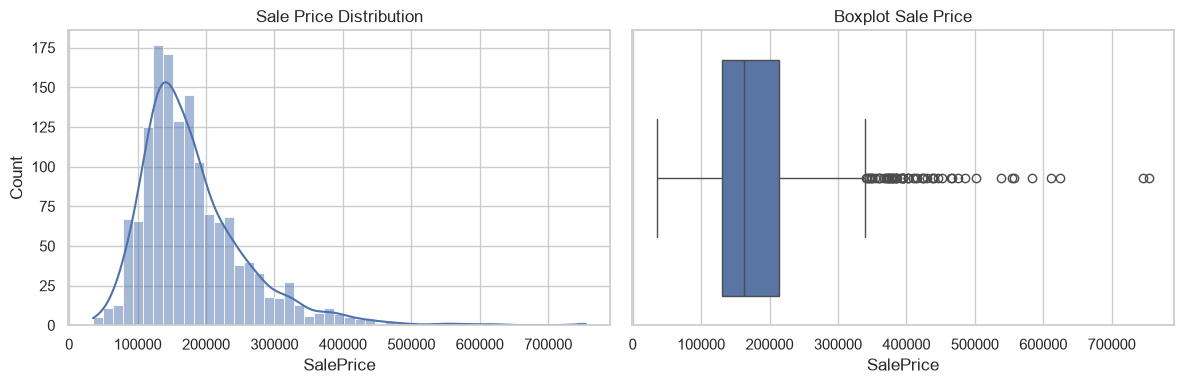

In [281]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('Sale Price Distribution')

sns.boxplot(x=df['SalePrice'], ax=axes[1])
axes[1].set_title('Boxplot Sale Price')

plt.tight_layout()
plt.show()

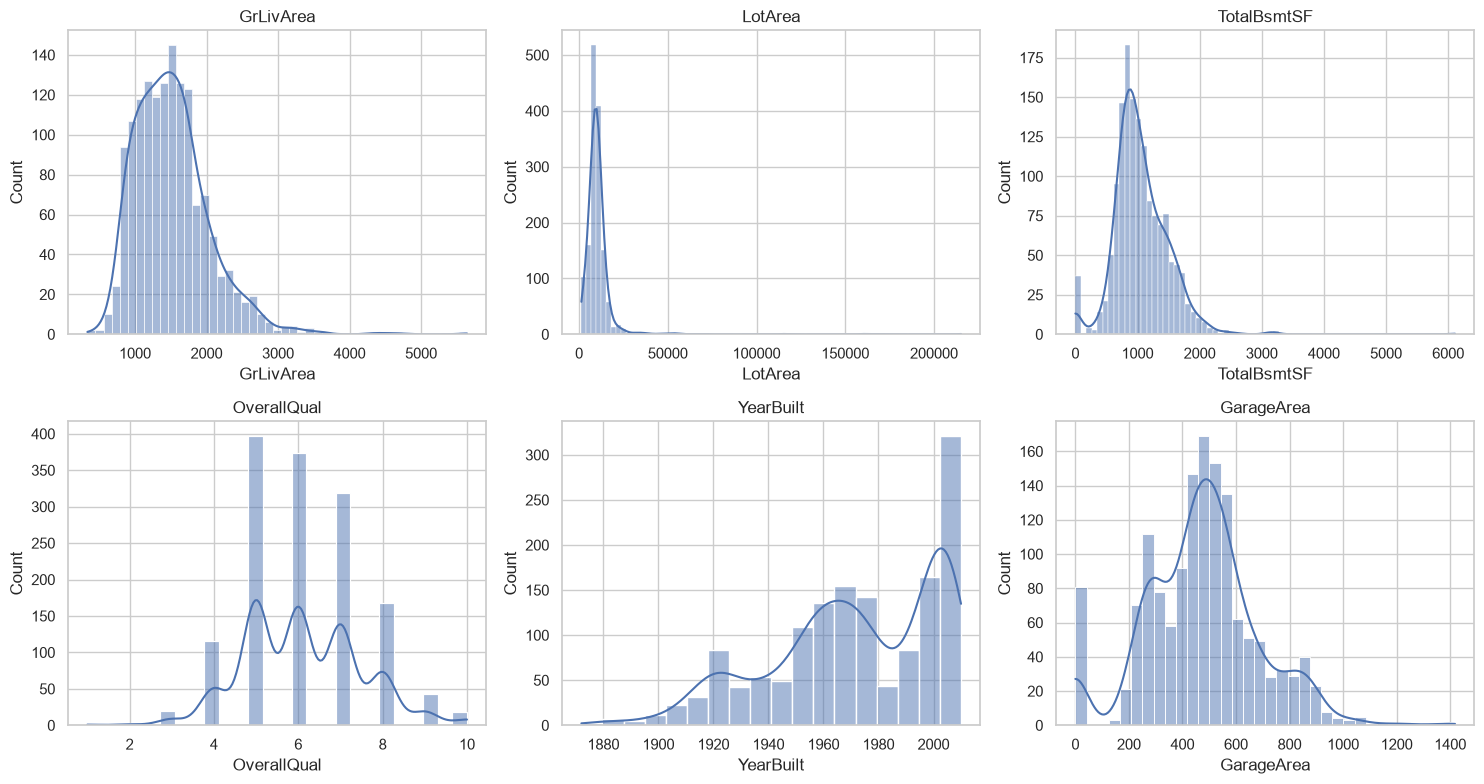

In [291]:
num_plot_cols = ['GrLivArea', 'LotArea', 'TotalBsmtSF', 'OverallQual', 'YearBuilt', 'GarageArea']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, c in zip(axes, num_plot_cols):
    sns.histplot(df[c].dropna(), kde=True, ax=ax)
    ax.set_title(c)

plt.tight_layout()
plt.show()

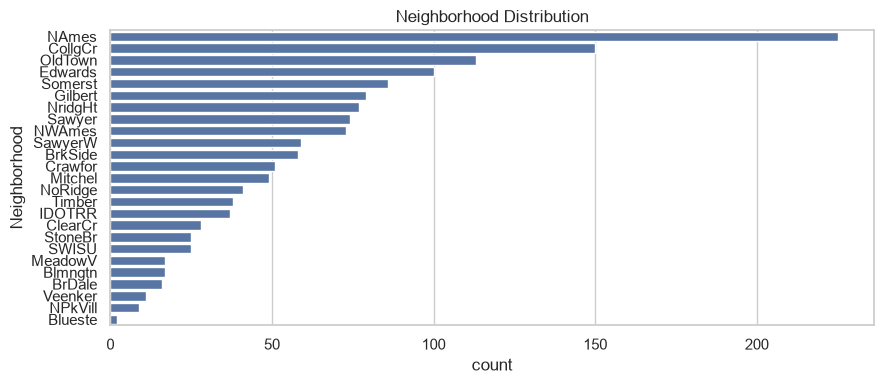

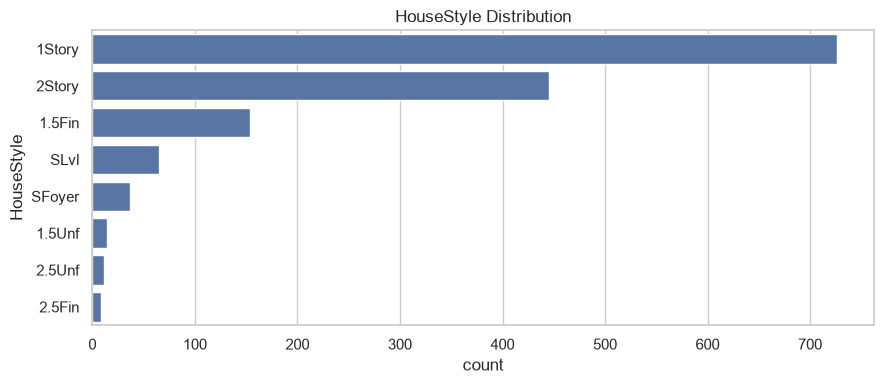

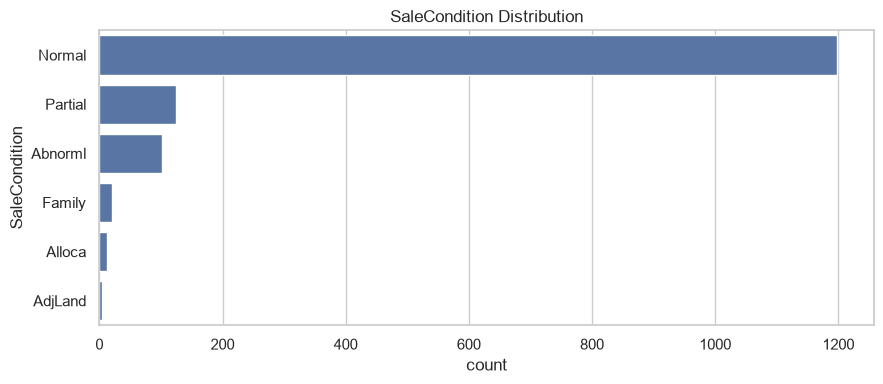

In [307]:
cat_plot_cols = ['Neighborhood', 'HouseStyle', 'SaleCondition']

for c in cat_plot_cols:
    plt.figure(figsize=(9,4))
    order = df[c].value_counts().index
    sns.countplot(df[c], order=order)
    plt.title(f'{c} Distribution')
    plt.tight_layout()
    plt.show()

### feature relationships

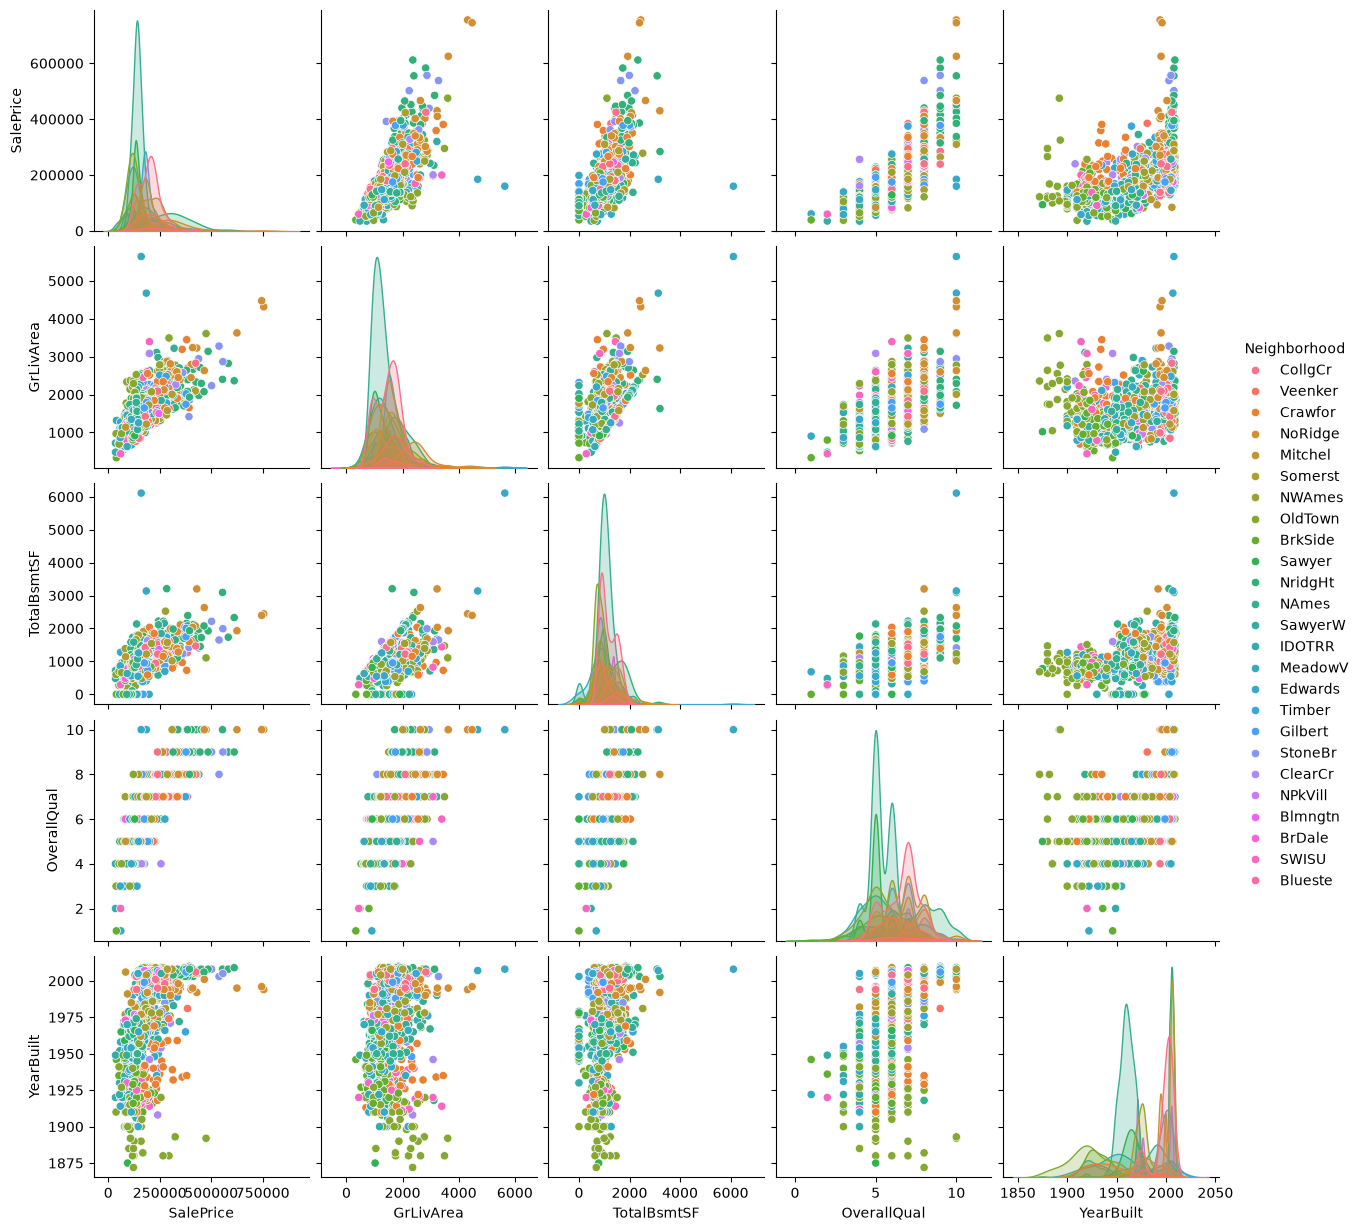

In [ ]:
sns.pairplot(df, vars=['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'OverallQual', 'YearBuilt'], 
       hue='Neighborhood',
       diag_kind='kde')

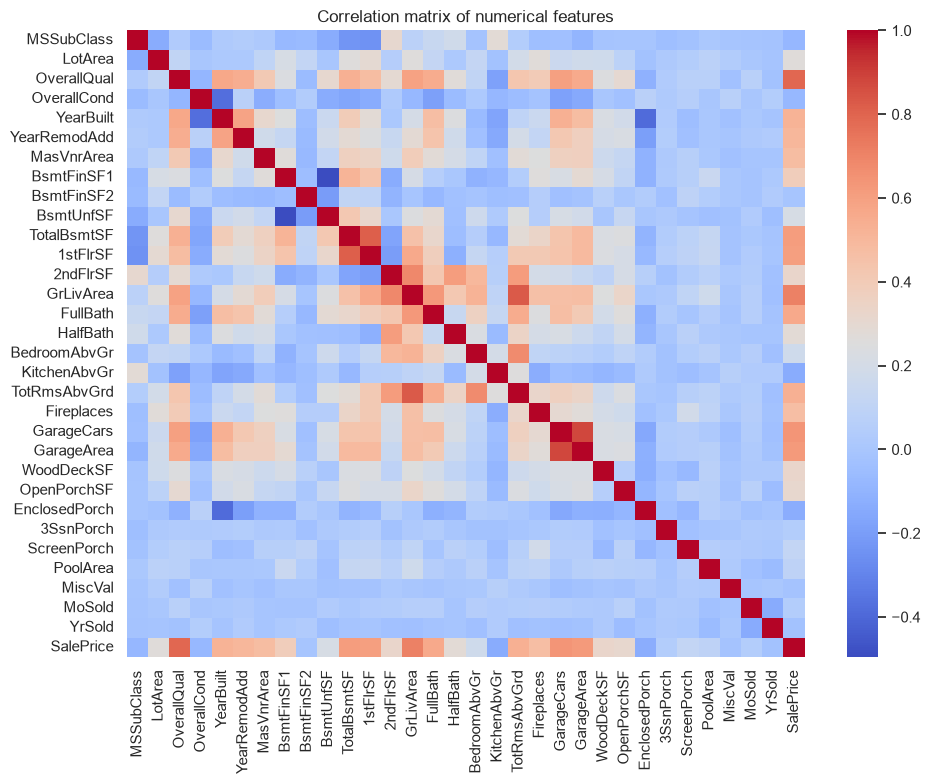

In [297]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].dropna().corr(), cmap='coolwarm')
plt.title('Correlation matrix of numerical features')
plt.tight_layout()
plt.show()

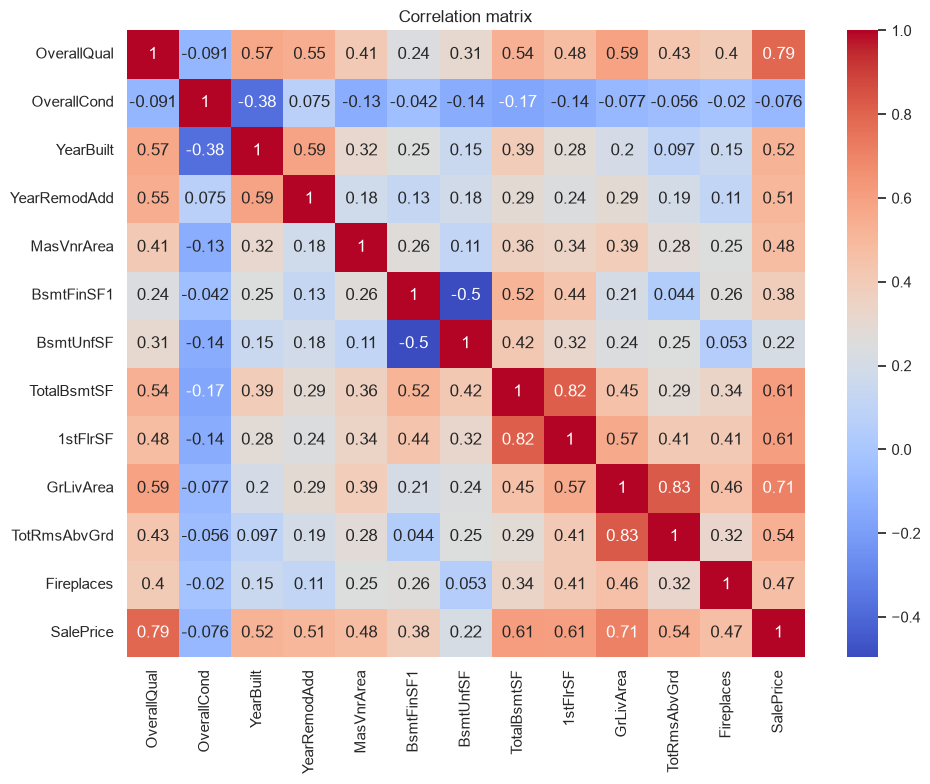

In [303]:
df_corr = df[[ 
       'OverallQual',
       'OverallCond',
       'YearBuilt',
       'YearRemodAdd',
       'MasVnrArea',
       'BsmtFinSF1',
       'BsmtUnfSF',
       'TotalBsmtSF',
       '1stFlrSF',
       'GrLivArea',
       'TotRmsAbvGrd',
       'Fireplaces',
       'SalePrice']].dropna().corr()
plt.figure(figsize=(10,8))
sns.heatmap(df_corr, cmap='coolwarm', annot=True)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

## 5. definition of input and output variables

In [356]:
TARGET = 'SalePrice'

X = df.drop(columns=[TARGET, 'Id'])
y = df[TARGET].copy()

print('X:', X.shape)
print('y:', y.shape)

X: (1460, 79)
y: (1460,)


## 6. split into training and test samples

In [357]:
price_bins = pd.qcut(y, q=5, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=price_bins
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (1168, 79) X_test: (292, 79)
y_train: (1168,) y_test: (292,)


### 7. processing of missed values

In [372]:
missing_train = X_train.isna().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
missing_train

LotFrontage    211
GarageYrBlt     63
MasVnrArea       8
dtype: int64

In [370]:
none_means_absence = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 
       'GarageType', 'GarageCond', 'GarageFinish', 'GarageQual', 'BsmtFinType2', 
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1']

for col in none_means_absence:
    X_train[col] = X_train[col].fillna('None')
    X_test[col] = X_test[col].fillna('None')

In [374]:
categorical_cols = X_train.select_dtypes(include=['str']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

remaining_cat = [c for c in categorical_cols if X_train[c].isna().any()]
remaining_num = [c for c in numeric_cols if X_train[c].isna().any()]

cat_imputer = SimpleImputer(strategy='most_frequent')
if remaining_cat:
    cat_imputer.fit(X_train[remaining_cat])
    X_train[remaining_cat] = cat_imputer.transform(X_train[remaining_cat])
    X_test[remaining_cat] = cat_imputer.transform(X_test[remaining_cat])
print('Filled with mode:', remaining_cat)


num_imputer = SimpleImputer(strategy='median')
if remaining_num:
    cat_imputer.fit(X_train[remaining_num])
    X_train[remaining_num] = cat_imputer.transform(X_train[remaining_num])
    X_test[remaining_num] = cat_imputer.transform(X_test[remaining_num])
print('Filled with median:', remaining_num)


Filled with mode: []
Filled with median: ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
